# Netflix Movies and TV Shows Clustering


# Executive Summary

This project analyzes Netflix Movies and TV Shows using Natural Language Processing and Unsupervised Machine Learning techniques. After data cleaning, exploratory analysis, and text preprocessing, TF-IDF and TruncatedSVD were used to transform textual information into numerical features. Two clustering algorithms, KMeans and Agglomerative Clustering, were evaluated. KMeans achieved the best clustering performance and identified seven meaningful content groups including Action Movies, Family Content, International TV Shows, Documentaries, and Stand-Up Comedy. The resulting clusters provide actionable insights for recommendation systems, content acquisition, and marketing strategies.

Github Link : https://github.com/Yogesh-46/Netflix_movies_tvshows_clustering

# Table of Contents

1. Problem Statement
2. Business Objective
3. Dataset Description
4. Data Cleaning
5. Missing Value Treatment
6. Outlier Analysis
7. Exploratory Data Analysis
8. Feature Engineering
9. Text Preprocessing
10. TF-IDF Vectorization
11. Dimensionality Reduction
12. KMeans Clustering
13. Agglomerative Clustering
14. Model Comparison
15. Cluster Interpretation
16. Stakeholder Impact
17. Conclusion

## Problem Statement

Netflix hosts thousands of movies and TV shows across different genres, countries, and categories. With such a large content library, it becomes challenging to understand hidden patterns among titles and organize content effectively.

The objective of this project is to analyze Netflix content and group similar titles using unsupervised machine learning techniques. By applying Natural Language Processing (NLP) and clustering algorithms, we aim to identify meaningful clusters of content based on textual information such as descriptions, genres, and directors.

## Business Objective

* Discover hidden content groups within Netflix's catalog.
* Support recommendation systems by identifying similar content.
* Help content acquisition teams understand content distribution.
* Assist marketing teams in targeting audience segments more effectively.

## Dataset Information

The dataset contains information about Netflix movies and TV shows, including:

show_id : Unique ID for every Movie / Tv Show

type : Identifier - A Movie or TV Show

title : Title of the Movie / Tv Show

director : Director of the Movie

cast : Actors involved in the movie / show

country : Country where the movie / show was produced

date_added : Date it was added on Netflix

release_year : Actual Releaseyear of the movie / show

rating : TV Rating of the movie / show

duration : Total Duration - in minutes or number of seasons

listed_in : Genere

description: The Summary description


#Importing Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import TruncatedSVD, PCA

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Plot style
sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
df = pd.read_csv('/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

print("Shape:", df.shape)

df.head()

Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## Basic Data Exploration

In this section, we examine the structure of the dataset, data types, missing values, and duplicate records before performing any preprocessing.

In [3]:
# Dataset Shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\n")
df.info()

Rows : 7787
Columns : 12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [4]:
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': round((df.isnull().sum()/len(df))*100,2),
    'Unique Values': df.nunique()
})

summary

,Data Type,Missing Values,Missing %,Unique Values
show_id,object,0,0.00,7787
type,object,0,0.00,2
title,object,0,0.00,7787
director,object,2389,30.68,4049
cast,object,718,9.22,6831
country,object,507,6.51,681
date_added,object,10,0.13,1565
release_year,int64,0,0.00,73
rating,object,7,0.09,14
duration,object,0,0.00,216


In [5]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records : {duplicate_count}")

Duplicate Records : 0


## Missing Value Treatment

Several columns contain missing values. Since clustering relies heavily on textual information, missing values must be handled appropriately before preprocessing.

Different strategies are applied depending on the nature of each feature.

In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


In [7]:
# Director
df['director'] = df['director'].fillna('Unknown')

# Cast
df['cast'] = df['cast'].fillna('Unknown')

# Country
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Rating
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Date Added
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Feature Engineering

In [9]:
#Convert Date Column
df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    errors='coerce'
)

In [10]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [11]:
from datetime import datetime

current_year = datetime.now().year

df['content_age'] = current_year - df['release_year']

In [12]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)

movies_df = df[df['type'] == 'Movie'].copy()
tv_df = df[df['type'] == 'TV Show'].copy()

print("Movies:", movies_df.shape)
print("TV Shows:", tv_df.shape)

Movies: (5377, 16)
TV Shows: (2410, 16)


In [13]:
movies_df['duration_num'] = movies_df['duration'].str.extract('(\d+)').astype(int)

In [14]:
Q1 = movies_df['duration_num'].quantile(0.25)
Q3 = movies_df['duration_num'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = movies_df[
    (movies_df['duration_num'] < lower_bound) |
    (movies_df['duration_num'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 337


### Outlier Analysis Conclusion

A total of 337 movie duration observations were identified as outliers using the IQR method. Further investigation revealed that these observations correspond to legitimate Netflix titles such as The Irishman and Lagaan. Therefore, the outliers were retained because they represent genuine business observations rather than data quality issues.

# Exploratory Data Analysis (EDA)

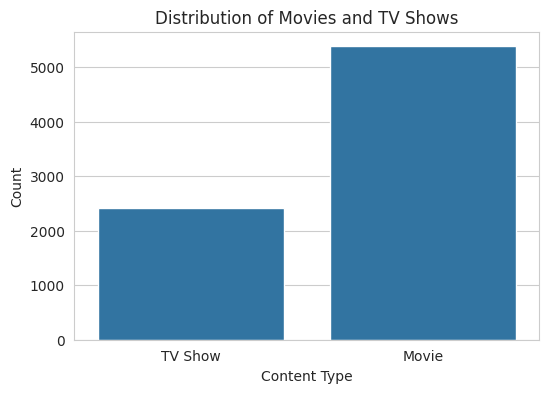

In [15]:
#Movies Vs TV Shows
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

Netflix's catalog is heavily dominated by movies, with approximately 69% Movies and 31% TV Shows.
This suggests that Netflix has historically focused more on movie content than episodic content.
The larger movie library provides users with a wider variety of one-time viewing options.
From a business perspective, movie production and acquisition appear to be a major content strategy for Netflix.

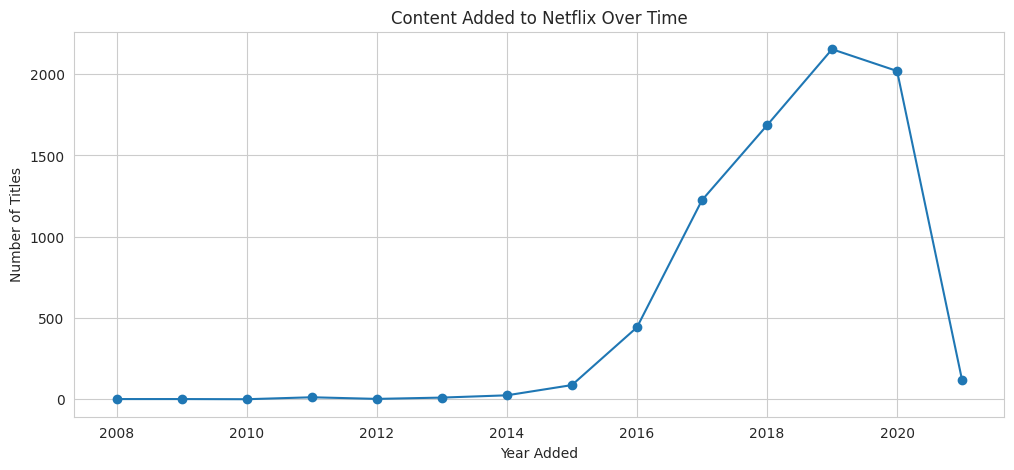

In [16]:
#Content added overtime
content_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

content_year.plot(kind='line', marker='o')

plt.title('Content Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.show()

Netflix content additions remained relatively low before 2015.
A significant surge in content acquisition began after 2016.
The platform experienced its fastest growth between 2017 and 2020.
This period reflects Netflix's aggressive global expansion and investment in original content.
The drop observed in 2021 is likely due to incomplete data collection for that year rather than an actual decline in content strategy.

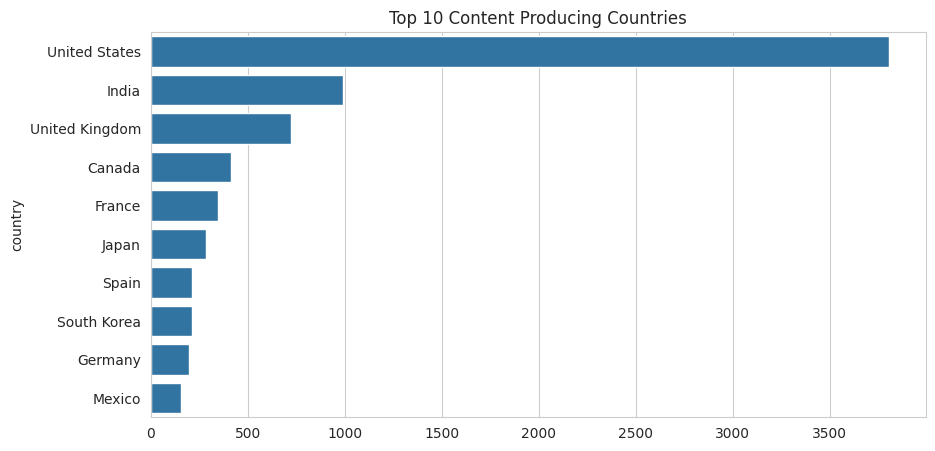

In [17]:
#Top 10 Coutries

country_df = df.copy()

country_df['country'] = country_df['country'].str.split(',')

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip()

top_countries = country_df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Content Producing Countries')

plt.show()

The United States dominates Netflix's content library by a substantial margin.
India ranks second, highlighting Netflix's strong presence in the Indian entertainment market.
Countries such as the United Kingdom, Canada, France, Japan, and South Korea also contribute significantly.
The distribution indicates Netflix's strategy of maintaining a globally diversified content portfolio.
The growing contribution from Asian countries demonstrates increasing demand for regional content.

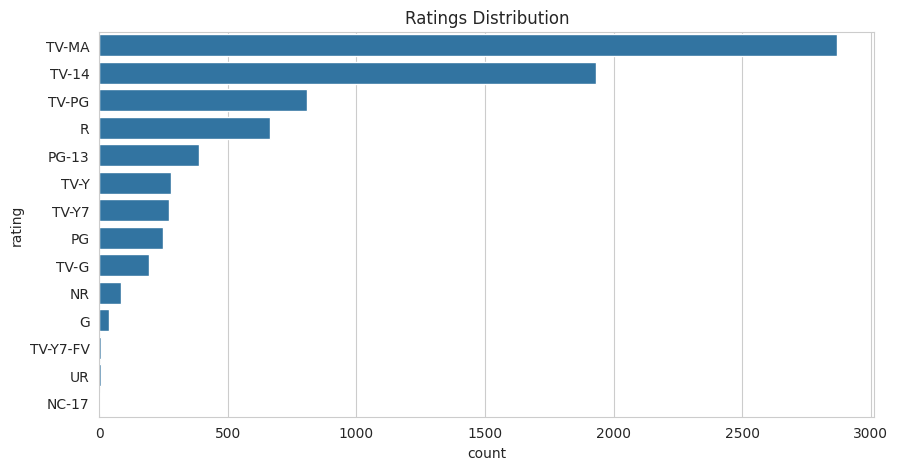

In [18]:
#Rating Distribution

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)

plt.title('Ratings Distribution')

plt.show()

TV-MA is the most common rating category on Netflix.
Adult-oriented content constitutes a large portion of the platform's catalog.
TV-14 is the second most frequent rating, indicating substantial content targeted toward teenagers and young adults.
Family-friendly categories such as TV-Y and TV-G represent a smaller portion of the library.
This distribution suggests that Netflix primarily targets mature audiences.

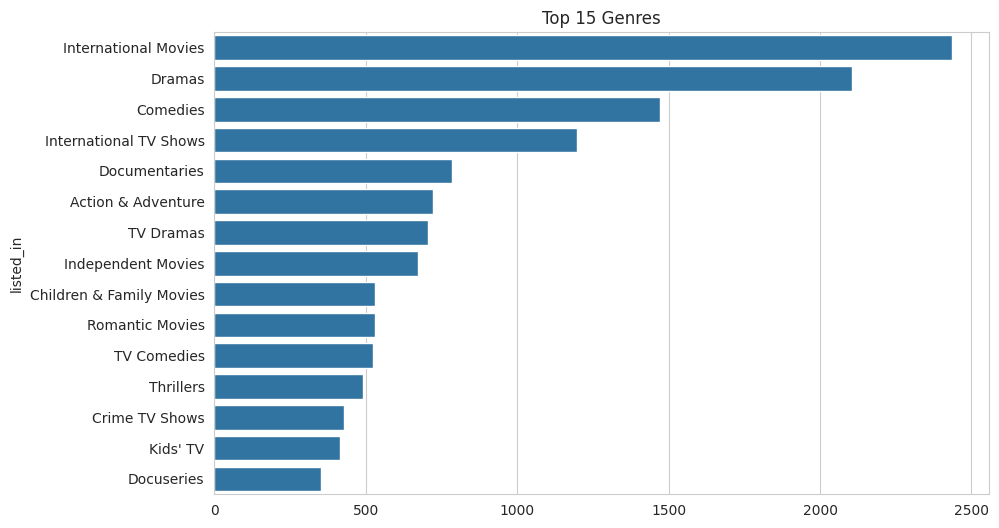

In [19]:
#Top 15 Genres

genre_df = df.copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(',')

genre_df = genre_df.explode('listed_in')

genre_df['listed_in'] = genre_df['listed_in'].str.strip()

top_genres = genre_df['listed_in'].value_counts().head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Genres')

plt.show()

International Movies represent the largest genre category.
Drama and Comedy are among the most dominant genres.
The strong presence of International TV Shows indicates Netflix's focus on global content consumption.
Documentary content also maintains a significant presence, reflecting audience interest in educational and factual entertainment.
The diversity of genres demonstrates Netflix's attempt to cater to a broad range of viewer preferences.

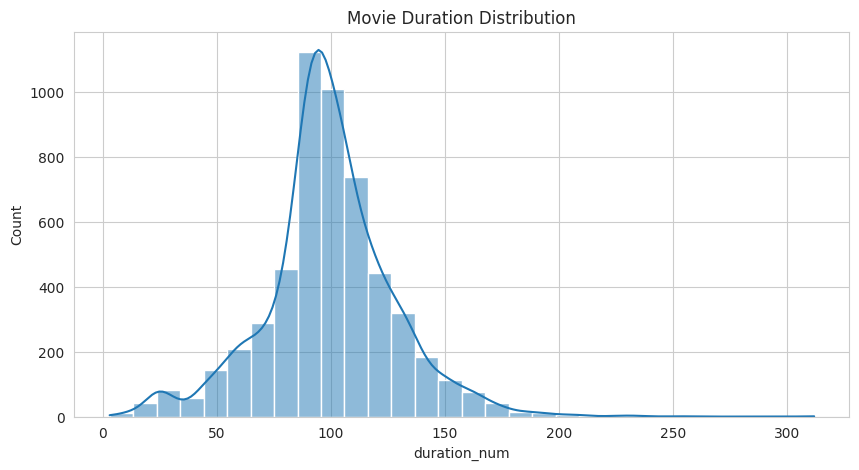

In [20]:
#Movie Duration Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    movies_df['duration_num'],
    bins=30,
    kde=True
)

plt.title('Movie Duration Distribution')

plt.show()

Most movies fall within the 80 to 120-minute range.
The distribution is slightly right-skewed due to a smaller number of exceptionally long movies.
The average movie duration appears to be around 100 minutes.
Extremely long movies are relatively rare but contribute to the identified outliers.
This indicates industry-standard movie lengths dominate Netflix's catalog.

# Exceptional Case Analysis

To better understand the dataset, several exceptional cases such as the longest movies, oldest releases, most frequent ratings, and country-wise dominance were examined.

In [21]:
movies_df.sort_values(
    'duration_num',
    ascending=False
)[['title','duration_num']].head(10)

,title,duration_num
957,Black Mirror: Bandersnatch,312
6850,The School of Mischief,253
4490,No Longer kids,237
3694,Lock Your Girls In,233
5108,Raya and Sakina,230
5376,Sangam,228
3521,Lagaan,224
3195,Jodhaa Akbar,214
3282,Kabhi Khushi Kabhie Gham,209
6507,The Irishman,209


In [22]:
df.sort_values(
    'release_year'
)[['title','release_year']].head(10)

,title,release_year
4867,Pioneers: First Women Filmmakers*,1925
6117,The Battle of Midway,1942
4960,Prelude to War,1942
7342,Undercover: How to Operate Behind Enemy Lines,1943
7679,WWII: Report from the Aleutians,1943
7616,Why We Fight: The Battle of Russia,1943
6657,The Memphis Belle: A Story of a\nFlying Fortress,1944
6699,The Negro Soldier,1944
7268,Tunisian Victory,1944
5371,San Pietro,1945


In [23]:
df.sort_values(
    'release_year',
    ascending=False
)[['title','release_year']].head(10)

,title,release_year
1285,Charming,2021
2327,Gabby's Dollhouse,2021
4390,Nailed It! Mexico,2021
2672,Headspace Guide to Meditation,2021
7551,What Happened to Mr. Cha?,2021
980,Bling Empire,2021
7220,Tribhanga - Tedhi Medhi Crazy,2021
4086,Mighty Little Bheem: Kite Festival,2021
1222,Carmen Sandiego,2021
6701,The Netflix Afterparty,2021


In [24]:
country_df['country'].value_counts().head(10)

,count
country,
United States,3804
India,990
United Kingdom,723
Canada,412
France,349
Japan,287
Spain,215
South Korea,212
Germany,199


In [25]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,2870
TV-14,1931
TV-PG,806
R,665
PG-13,386
TV-Y,280
TV-Y7,271
PG,247
TV-G,194


In [26]:
outliers[['title', 'duration', 'duration_num', 'release_year']] \
    .sort_values('duration_num', ascending=False) \
    .head(10)

,title,duration,duration_num,release_year
957,Black Mirror: Bandersnatch,312 min,312,2018
6850,The School of Mischief,253 min,253,1973
4490,No Longer kids,237 min,237,1979
3694,Lock Your Girls In,233 min,233,1982
5108,Raya and Sakina,230 min,230,1984
5376,Sangam,228 min,228,1964
3521,Lagaan,224 min,224,2001
3195,Jodhaa Akbar,214 min,214,2008
6507,The Irishman,209 min,209,2019
3282,Kabhi Khushi Kabhie Gham,209 min,209,2001


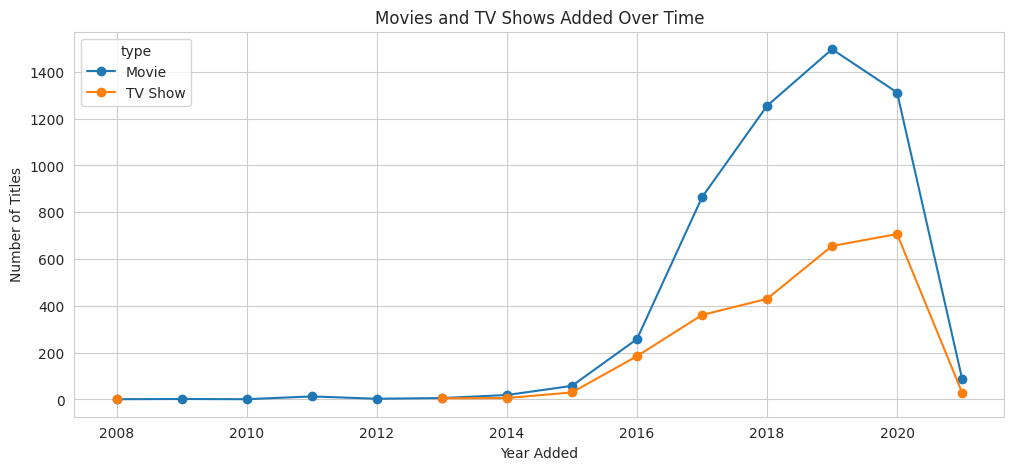

In [27]:
#Movies & TV Shows Added Over Time

content_trend = df.groupby(['year_added','type']).size().unstack()

content_trend.plot(
    figsize=(12,5),
    marker='o'
)

plt.title('Movies and TV Shows Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

Both Movies and TV Shows experienced rapid growth after 2016.
Movie additions consistently exceeded TV Show additions throughout the observed period.
The gap between Movies and TV Shows widened significantly between 2017 and 2020.
This suggests Netflix prioritized expanding its movie catalog during its rapid growth phase.
TV Show content also increased steadily, reflecting growing investment in series-based entertainment.

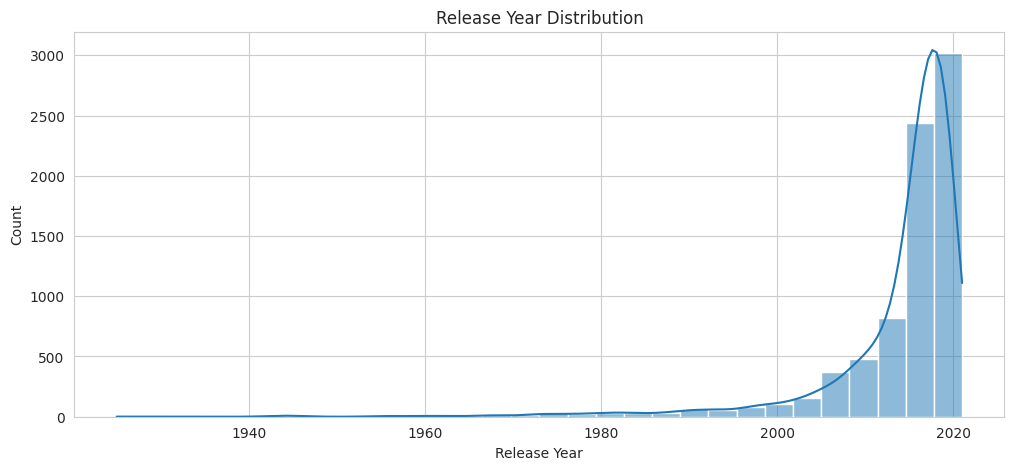

In [28]:
#Release Year Distribution

plt.figure(figsize=(12,5))

sns.histplot(
    df['release_year'],
    bins=30,
    kde=True
)

plt.title('Release Year Distribution')
plt.xlabel('Release Year')

plt.show()

The majority of Netflix titles were released after the year 2000.
Content production accelerates noticeably after 2010.
Older content from before 1990 forms only a small portion of the library.
Netflix appears to prioritize relatively recent content that aligns with modern audience preferences.
The distribution reflects a strong emphasis on contemporary entertainment.

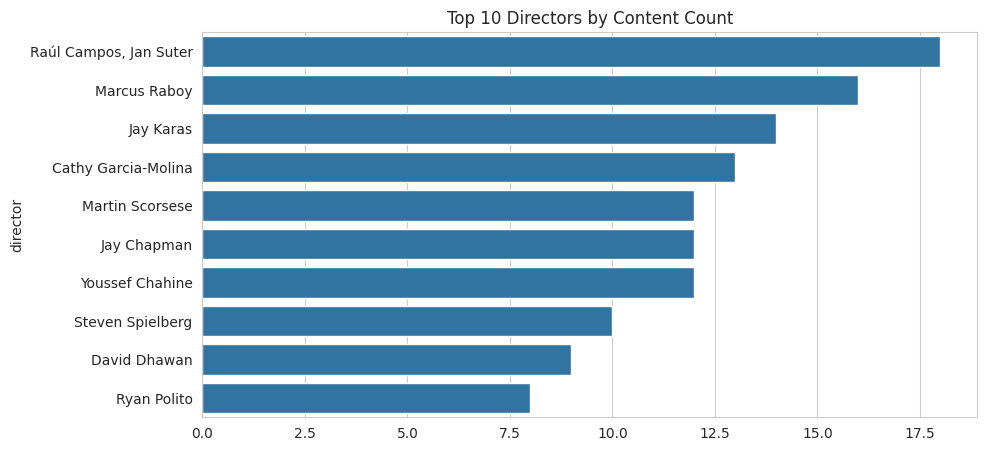

In [29]:
#Top Directors by Content Count

director_df = df[df['director'] != 'Unknown']

top_directors = director_df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title('Top 10 Directors by Content Count')

plt.show()

A small number of directors contribute multiple titles to Netflix's catalog.
Directors such as Raúl Campos & Jan Suter and Marcus Raboy appear frequently due to repeated comedy specials and stand-up content.
The distribution indicates Netflix maintains long-term relationships with certain creators and production teams.
Content production is not concentrated around a single director, indicating healthy diversity in content creation.

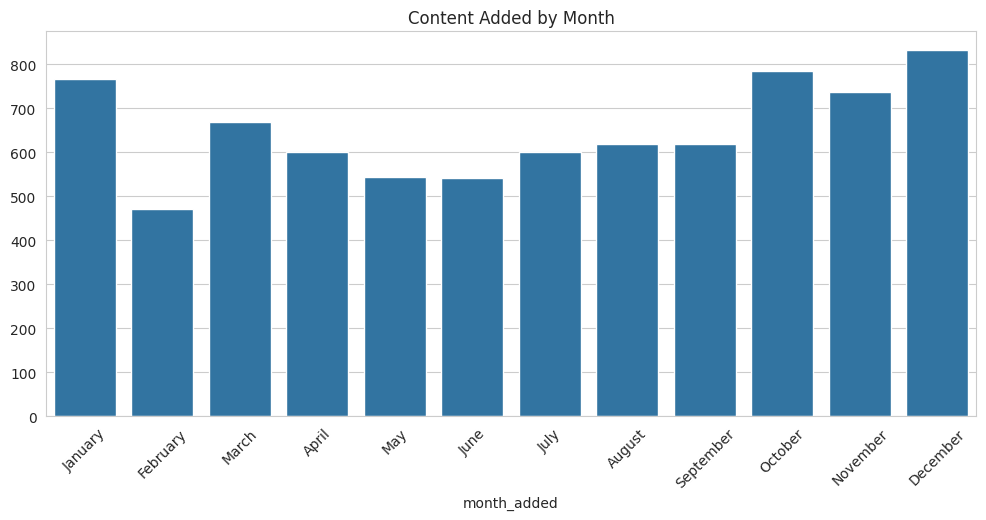

In [30]:
#Content Added by Month

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly.index,
    y=monthly.values
)

plt.xticks(rotation=45)

plt.title('Content Added by Month')

plt.show()

Content additions occur throughout the year rather than being concentrated in a single season.
October, November, December, and January show relatively higher content additions.
Netflix may strategically release additional content during holiday and year-end viewing periods.
February records comparatively fewer additions.
The overall distribution suggests a continuous content release strategy.

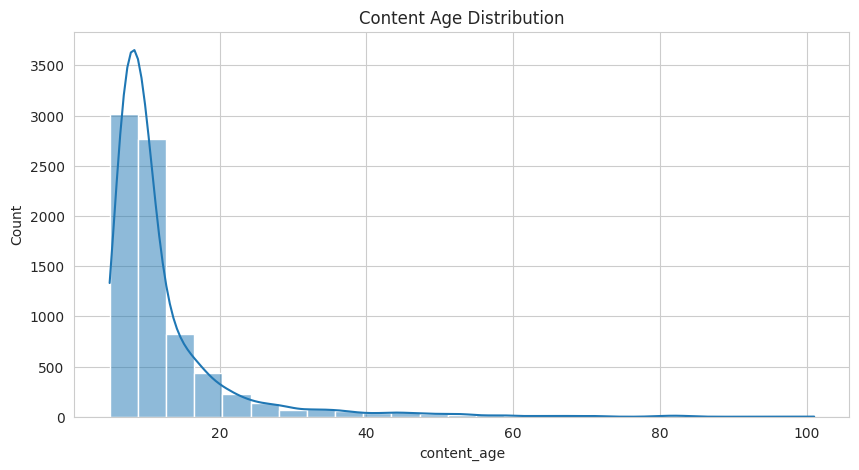

In [31]:
#Content Age Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['content_age'],
    bins=25,
    kde=True
)

plt.title('Content Age Distribution')

plt.show()

Most Netflix content is less than 15 years old.
The distribution is heavily skewed toward newer content.
Very old content exists but represents a small proportion of the library.
This supports Netflix's strategy of maintaining a fresh and contemporary catalog.
Newer titles are likely prioritized to improve viewer engagement and retention.

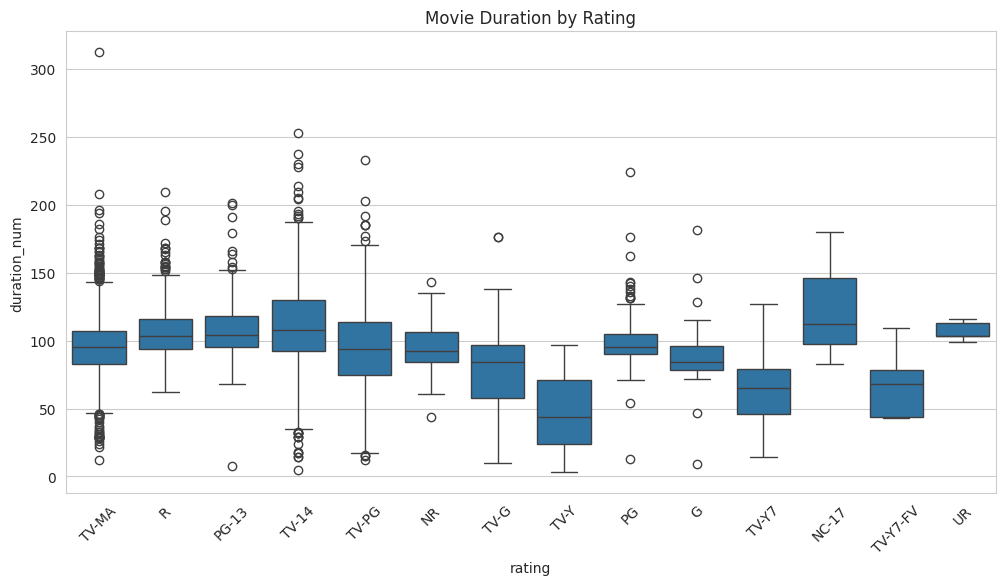

In [32]:
#Movie Duration by Rating


plt.figure(figsize=(12,6))

sns.boxplot(
    data=movies_df,
    x='rating',
    y='duration_num'
)

plt.xticks(rotation=45)

plt.title('Movie Duration by Rating')

plt.show()

Movie duration varies across rating categories.
Adult-oriented ratings such as TV-MA and R exhibit wider duration distributions.
Family-oriented categories generally show shorter and more consistent runtimes.
Some rating categories contain extreme duration outliers, representing special productions and long-form content.
The variation suggests that content maturity level may influence production format and storytelling length.

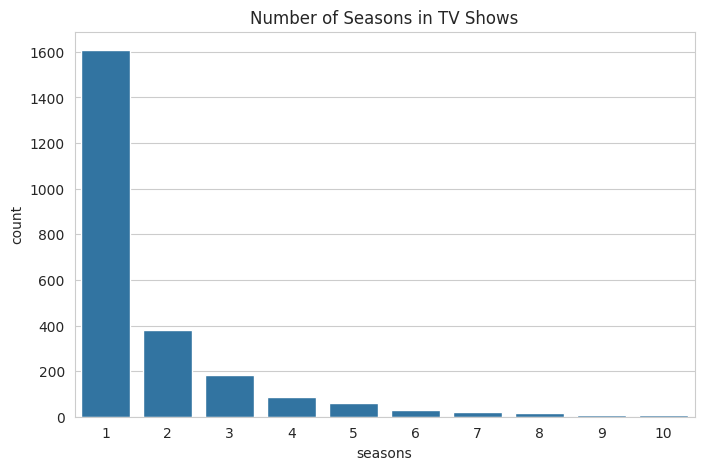

In [33]:
#Number of Seasons in TV Shows

tv_df['seasons'] = tv_df['duration_num']

plt.figure(figsize=(8,5))

sns.countplot(
    x='seasons',
    data=tv_df,
    order=tv_df['seasons'].value_counts().index[:10]
)

plt.title('Number of Seasons in TV Shows')

plt.show()

Most TV Shows have only one season.
The frequency decreases significantly as the number of seasons increases.
Long-running TV Shows represent a relatively small portion of the catalog.
Netflix appears to invest heavily in limited-series formats and short-run productions.
This trend aligns with modern streaming consumption patterns where viewers prefer shorter commitments.

# **Key Findings from Exploratory Data Analysis**
Netflix's catalog is dominated by Movies, accounting for nearly 70% of all content.

The platform experienced explosive growth between 2016 and 2020, reflecting major investments in content acquisition and production.

The United States is the largest content contributor, followed by India, highlighting Netflix's strong international presence.

Adult-oriented content (TV-MA and TV-14) forms the majority of the platform's library.

International Movies, Dramas, and Comedies are the most prevalent genres.

Most movies have durations between 80 and 120 minutes, while most TV Shows contain only one season.

Netflix strongly favors recent content, with the majority of titles released after 2000 and most content being less than 15 years old.

Seasonal release patterns suggest increased content additions during the final quarter of the year.

Outlier analysis revealed several unusually long movies; however, these were verified as legitimate titles and retained for further analysis.

Overall, the EDA indicates that Netflix follows a globally diversified content strategy focused on recent, internationally appealing, and mature-audience-oriented entertainment.

# Feature Engineering for Clustering

To improve cluster quality, a new feature named combined_text was created by merging genre information (listed_in), director information (director), and content descriptions (description). This provides richer contextual information compared to using descriptions alone and helps clustering algorithms identify more meaningful content similarities.

In [34]:
df['combined_text'] = (
    df['listed_in'].astype(str) + ' ' +
    df['director'].astype(str) + ' ' +
    df['description'].astype(str)
)

df[['listed_in', 'director', 'description', 'combined_text']].head(3)

,listed_in,director,description,combined_text
0,"International TV Shows, TV Dramas, TV Sci-Fi &...",Unknown,In a future where the elite inhabit an island ...,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,"Dramas, International Movies",Jorge Michel Grau,After a devastating earthquake hits Mexico Cit...,"Dramas, International Movies Jorge Michel Grau..."
2,"Horror Movies, International Movies",Gilbert Chan,"When an army recruit is found dead, his fellow...","Horror Movies, International Movies Gilbert Ch..."


In [35]:
import re
import string

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)



In [36]:
df['clean_text'] = df['combined_text'].apply(clean_text)

Text preprocessing was performed to improve the quality of textual features. The process included converting text to lowercase, removing punctuation and numbers, eliminating stopwords, and applying lemmatization. These steps reduce noise and improve the effectiveness of TF-IDF vectorization and clustering algorithms.

# TF-IDF Vectorization

The cleaned textual data was transformed into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency). A maximum of 5000 features was retained, and both unigrams and bigrams were considered to capture meaningful phrases. This representation enables machine learning algorithms to identify similarities between Netflix titles based on textual content.

## Why TF-IDF?

TF-IDF was selected because it captures the importance of words within documents while reducing the influence of frequently occurring but less informative terms.

Compared to Bag of Words, TF-IDF generally produces better text representations for clustering tasks.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])

In [38]:
print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (7787, 5000)


# Dimensionality Reduction using TruncatedSVD

The TF-IDF representation generated 5000 textual features. To reduce dimensionality and improve clustering performance, TruncatedSVD was applied. The number of dimensions was reduced to 100 while preserving a significant portion of the original information contained in the text data.

## Why TruncatedSVD?

The TF-IDF matrix contains 5000 sparse textual features. TruncatedSVD was applied to reduce dimensionality while preserving important information. Unlike PCA, TruncatedSVD works efficiently on sparse matrices and is commonly used in NLP applications.

In [39]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_svd = svd.fit_transform(X)

print("Reduced Shape:", X_svd.shape)

Reduced Shape: (7787, 100)


The dimensionality of the TF-IDF matrix was reduced from 5000 features to 100 components using TruncatedSVD. This reduced computational complexity while preserving meaningful textual information required for clustering.

In [40]:
explained_variance = svd.explained_variance_ratio_.sum()

print(
    f"Total Explained Variance: {explained_variance:.2%}"
)

Total Explained Variance: 21.87%


# Clustering Models
## KMeans Clustering

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_svd)

    score = silhouette_score(
        X_svd,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k} | Silhouette Score = {score:.4f}"
    )

K = 2 | Silhouette Score = 0.1545
K = 3 | Silhouette Score = 0.1086
K = 4 | Silhouette Score = 0.0720
K = 5 | Silhouette Score = 0.0804
K = 6 | Silhouette Score = 0.0656
K = 7 | Silhouette Score = 0.0943
K = 8 | Silhouette Score = 0.0707
K = 9 | Silhouette Score = 0.0853
K = 10 | Silhouette Score = 0.0871


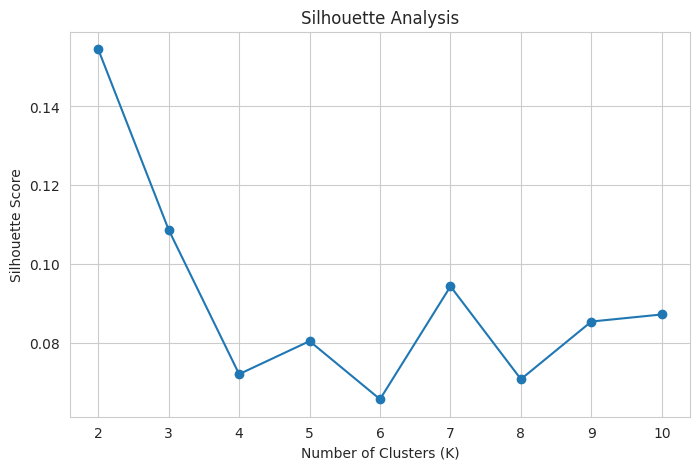

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [43]:
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(X_svd)

df['kmeans_cluster'].value_counts().sort_index()

,count
kmeans_cluster,
0,566
1,383
2,745
3,531
4,3052
5,1121
6,1389


In [44]:
for cluster in sorted(df['kmeans_cluster'].unique()):

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")

    sample_titles = df[
        df['kmeans_cluster'] == cluster
    ][['title','listed_in']].head(15)

    print(sample_titles)


CLUSTER 0
                              title  \
29                         #blackAF   
108        3Below: Tales of Arcadia   
111                         44 Cats   
225  A Series of Unfortunate Events   
259         A.D. Kingdom and Empire   
276                    Abby Hatcher   
289                   Absurd Planet   
306           Adam Ruins Everything   
357                AJ and the Queen   
364                    Akbar Birbal   
380                   Alexa & Katie   
396                        Alien TV   
404       All About the Washingtons   
411            All Hail King Julien   
412    All Hail King Julien: Exiled   

                                             listed_in  
29                                         TV Comedies  
108  Kids' TV, TV Action & Adventure, TV Sci-Fi & F...  
111                                           Kids' TV  
225       Kids' TV, TV Action & Adventure, TV Comedies  
259                                          TV Dramas  
276                   

# Cluster Formation Strategy

K-Means clustering was applied on the reduced TF-IDF feature space to identify groups of similar Netflix content. Although the highest silhouette score was achieved at K=2, the resulting clusters were too broad for meaningful business interpretation. Therefore, K=7 was selected as it provided a better balance between cluster quality and interpretability.

The resulting clusters revealed distinct content categories, including Action & Adventure Movies, Documentaries, International TV Shows, Family Movies, Stand-Up Comedy, Kids Entertainment, and Drama/Thriller content. These clusters demonstrate that textual information such as genres, directors, and descriptions can effectively group similar content together.

In [45]:
kmeans_silhouette = silhouette_score(
    X_svd,
    df['kmeans_cluster']
)

print("KMeans Silhouette Score:", round(kmeans_silhouette,4))

KMeans Silhouette Score: 0.0943


## Agglomerative Clustering

In [46]:
from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(
    n_clusters=7
)

df['agg_cluster'] = agglomerative.fit_predict(X_svd)

df['agg_cluster'].value_counts().sort_index()

,count
agg_cluster,
0,1724
1,3611
2,721
3,369
4,433
5,316
6,613


In [47]:
from sklearn.metrics import silhouette_score

agg_silhouette = silhouette_score(
    X_svd,
    df['agg_cluster']
)

print("Agglomerative Silhouette Score:", round(agg_silhouette,4))

Agglomerative Silhouette Score: 0.0706


# Model Evaluation and Selection


Two clustering algorithms were evaluated: KMeans and Agglomerative Clustering. The quality of clusters was assessed using the Silhouette Score metric.

KMeans achieved a Silhouette Score of 0.0943, whereas Agglomerative Clustering achieved a score of 0.0706. Since KMeans produced better-separated and more cohesive clusters, it was selected as the final model for cluster interpretation and business analysis.

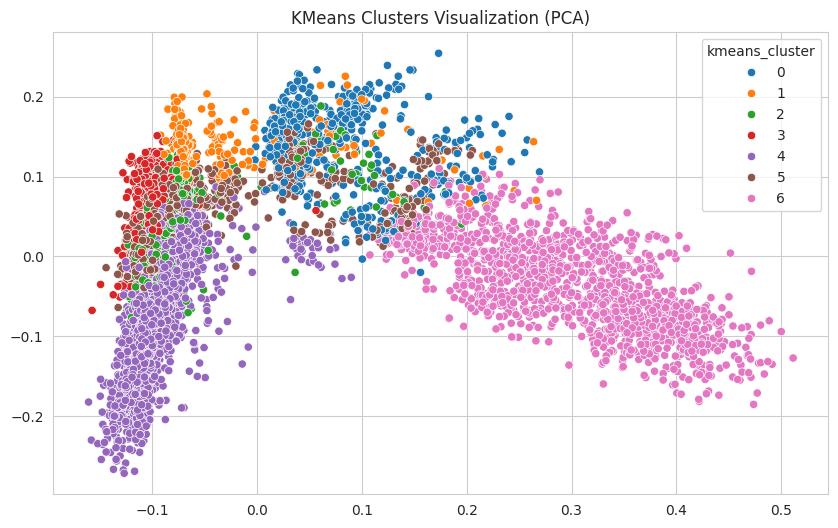

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_svd)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['kmeans_cluster'],
    palette='tab10',
    legend='full'
)

plt.title('KMeans Clusters Visualization (PCA)')
plt.show()

## Cluster Visualization

The PCA projection provides a two-dimensional representation of the clustered Netflix titles. Although some overlap exists between clusters due to the complexity of textual data, distinct content groupings can still be observed, demonstrating the effectiveness of the clustering approach.

In [49]:
comparison = pd.DataFrame({
    'Algorithm':['KMeans','Agglomerative Clustering'],
    'Silhouette Score':[0.0943,0.0706]
})

comparison

,Algorithm,Silhouette Score
0,KMeans,0.0943
1,Agglomerative Clustering,0.0706


### Model Comparison

KMeans achieved a higher Silhouette Score (0.0943) compared to Agglomerative Clustering (0.0706). Therefore, KMeans was selected as the final clustering algorithm for interpretation and business analysis.

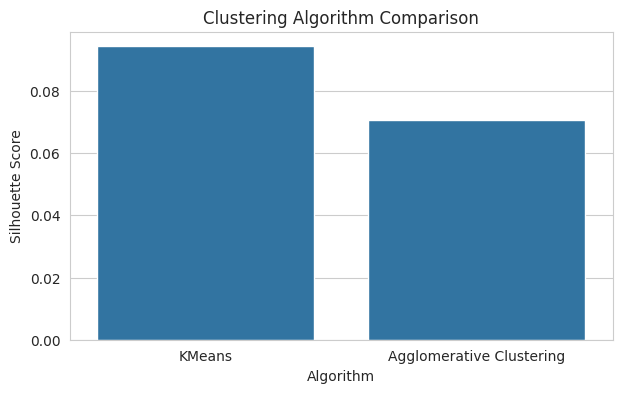

In [50]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x='Algorithm',
    y='Silhouette Score'
)

plt.title('Clustering Algorithm Comparison')

plt.show()

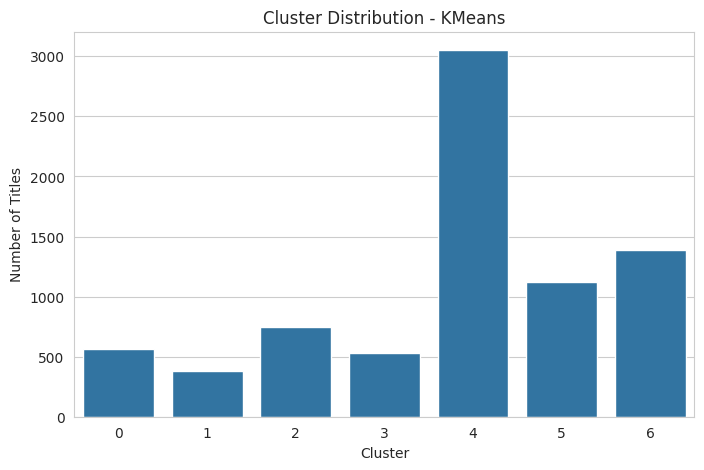

In [51]:
cluster_size = df['kmeans_cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_size.index,
    y=cluster_size.values
)

plt.title('Cluster Distribution - KMeans')

plt.xlabel('Cluster')
plt.ylabel('Number of Titles')

plt.show()

### Cluster Distribution Analysis

The clusters are reasonably distributed across the dataset. Although Cluster 4 contains a larger proportion of titles, all clusters contain a sufficient number of observations to support meaningful interpretation.

This indicates that the clustering process successfully identified major content segments within Netflix's catalog.

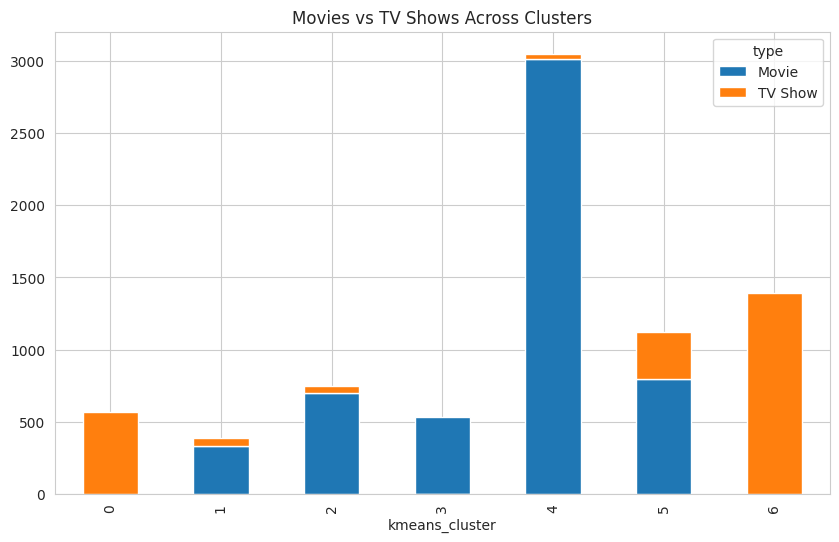

In [52]:
pd.crosstab(
    df['kmeans_cluster'],
    df['type']
)

cluster_type = pd.crosstab(
    df['kmeans_cluster'],
    df['type']
)

cluster_type.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Movies vs TV Shows Across Clusters')

plt.show()

In [53]:
for cluster in sorted(df['kmeans_cluster'].unique()):

    print("\n")
    print("="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    cluster_genres = (
        df[df['kmeans_cluster']==cluster]
        ['listed_in']
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
        .head(10)
    )

    print(cluster_genres)



Cluster 0
listed_in
Kids' TV                 413
TV Comedies              228
TV Dramas                 67
British TV Shows          30
TV Sci-Fi & Fantasy       29
TV Action & Adventure     27
TV Horror                 25
TV Mysteries              24
Korean TV Shows           23
Anime Series              22
Name: count, dtype: int64


Cluster 1
listed_in
Stand-Up Comedy                 329
Stand-Up Comedy & Talk Shows     49
TV Comedies                      35
International TV Shows           13
Music & Musicals                  6
Docuseries                        4
Comedies                          3
Documentaries                     2
TV Sci-Fi & Fantasy               1
TV Mysteries                      1
Name: count, dtype: int64


Cluster 2
listed_in
Action & Adventure       699
International Movies     353
Dramas                   197
Comedies                 157
Sci-Fi & Fantasy         105
TV Action & Adventure     44
Anime Features            35
Independent Movies        34


# Business Impact and Stakeholder Benefits

### Recommendation Team
Clusters can be used to recommend similar content to users.

### Content Acquisition Team
Cluster distribution helps identify content categories that dominate or are underrepresented.

### Marketing Team
Cluster-specific campaigns can improve audience targeting.

### Business Strategy Team
Content segmentation provides insights into Netflix's overall content portfolio.

# Future Work

Although the current project successfully identifies meaningful content clusters within Netflix's catalog, several improvements can be explored in future work.

1. More advanced text embedding techniques such as Word2Vec, GloVe, BERT, or Sentence Transformers can be used to capture deeper semantic relationships between titles.

2. Additional metadata such as cast members, ratings, countries, release years, and user engagement metrics can be incorporated to improve cluster quality.

3. Alternative clustering algorithms such as DBSCAN, Gaussian Mixture Models, and Spectral Clustering can be evaluated and compared.

4. Real user viewing behavior and watch-history data can be integrated to create personalized recommendation systems.

5. Automated cluster labeling techniques can be explored to improve interpretability and reduce manual analysis.

6. The clustering framework can be deployed as part of a content recommendation engine to support real-time content discovery.


# Conclusion

The objective of this project was to analyze and cluster Netflix Movies and TV Shows using Natural Language Processing and Unsupervised Machine Learning techniques.

The dataset was cleaned and preprocessed by handling missing values, analyzing outliers, performing feature engineering, and transforming textual information into a structured format suitable for machine learning. Exploratory Data Analysis revealed that Netflix's catalog is dominated by movies, contains a strong international presence, and primarily focuses on recent content targeted toward mature audiences.

For clustering, textual information from genres, directors, and content descriptions was combined and transformed using TF-IDF vectorization. TruncatedSVD was applied to reduce dimensionality and improve clustering efficiency.

Two clustering algorithms, KMeans and Agglomerative Clustering, were evaluated. Based on Silhouette Score comparison, KMeans achieved superior performance and was selected as the final clustering model.

The final clustering solution successfully identified seven meaningful content segments, including Action & Adventure Movies, Stand-Up Comedy, Children & Family Content, Documentaries, International TV Shows, and Drama/Thriller categories. These clusters demonstrate that textual information can effectively reveal hidden structures within large entertainment catalogs.

The insights generated from this analysis can support recommendation systems, content acquisition decisions, audience segmentation, and targeted marketing strategies. Overall, the project highlights the effectiveness of unsupervised learning techniques in extracting valuable business insights from large-scale streaming content datasets.

The project successfully demonstrates how unsupervised learning techniques can transform unstructured textual content into actionable business insights, making it a valuable approach for content discovery and recommendation systems.